In [4]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPVisionModel, CLIPImageProcessor

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:",device)

device: cuda


In [61]:
# 视觉编码器部分（不带 text encoder / projection head）
# 注意: openai/clip-vit-large-patch14 默认输入 224x224
model = CLIPVisionModel.from_pretrained("openai/clip-vit-large-patch14",attn_implementation="eager").to(device).eval()
processor = CLIPImageProcessor.from_pretrained("openai/clip-vit-large-patch14")

In [9]:
cfg = model.config

In [10]:
print("image_size",cfg.image_size,"| patch_size:", cfg.patch_size,
      "| hidden_size:",cfg.hidden_size,"| layers:", cfg.num_hidden_layers,"| heads:", cfg.num_attention_heads)

image_size 224 | patch_size: 14 | hidden_size: 1024 | layers: 24 | heads: 16


In [11]:
n_patch_per_side = cfg.image_size // cfg.patch_size
print(f"patch_grid:{n_patch_per_side}x{n_patch_per_side} = {n_patch_per_side**2} 个 patch token (+1 个 [CLS])")

patch_grid:16x16 = 256 个 patch token (+1 个 [CLS])


In [12]:
from pathlib import Path

image_path = "figures/llava_example_cmp.png"
if not Path(image_path).exists():
      import requests
      url = "https://raw.githubusercontent.com/haotian-liu/LLaVA/main/images/llava_example_cmp.png"
      open(image_path, "wb").write(requests.get(url).content)

In [14]:
image = Image.open(image_path).convert("RGB")
print("原始尺寸:", image.size)

原始尺寸: (1280, 720)


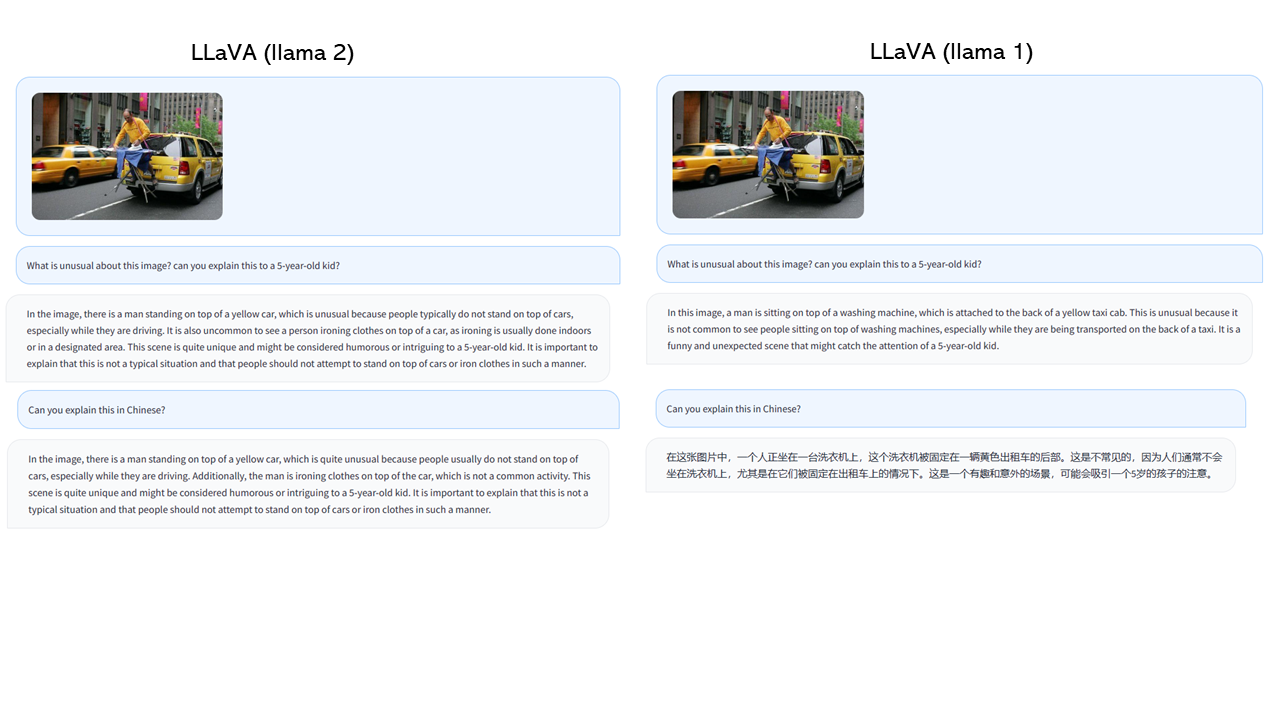

In [15]:
image

In [18]:
# 前向传播
with torch.no_grad():
    inputs = processor(images=image, return_tensors="pt").to(device)
    print("预处理后的输入 Shape:",inputs["pixel_values"].shape)
    outs = model(**inputs, output_hidden_states=True)
hs = outs.hidden_states
print("hidden_states 数量:", len(hs))
print("每层输出:", hs[0].shape)

预处理后的输入 Shape: torch.Size([1, 3, 224, 224])
hidden_states 数量: 25
每层输出: torch.Size([1, 257, 1024])


In [23]:
hs[24] == hs[-1]

tensor([[[True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         ...,
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True]]], device='cuda:0')

In [24]:
embeddings = hs[0]
before_last = hs[-2]
after_last = hs[-1]
after_lastLN = outs.last_hidden_state

In [26]:
for name, f in [("embeddings", embeddings), ("before L24", before_last),
                  ("after L24", after_last), ("after L24+LN", after_lastLN)]:
    print(f"{name:>14}:  {tuple(f.shape)}")

    embeddings:  (1, 257, 1024)
    before L24:  (1, 257, 1024)
     after L24:  (1, 257, 1024)
  after L24+LN:  (1, 257, 1024)


In [31]:
# (1, 257, 1024) 中取 [:, 0, :]  → (1, 1024)   —— 只留下 CLS 那一个 1024 维向量
# (1, 257, 1024) 中取 [:, 1:256, :] → (1, 256, 1024) —— 256 个 patch token 全部保留
def split_cls_grid(embed):
    return embed[:, 0], embed[:, 1:] 


In [30]:
cls_before, grid_before = split_cls_grid(before_last) # LLaVA 最终用的: hidden_states[-2], 丢 CLS
cls_last,   grid_last   = split_cls_grid(after_last)
print("LLaVA 用的 grid features  shape:", tuple(grid_before.shape),"→ 展平后每个位置是", grid_before.shape[-1], "维向量")
print("同一层取出的 CLS shape:", tuple(cls_before.shape), "→ 整张图只有 1 个这样的向量")

LLaVA 用的 grid features  shape: (1, 256, 1024) → 展平后每个位置是 1024 维向量
同一层取出的 CLS shape: (1, 1024) → 整张图只有 1 个这样的向量


In [32]:
 def l2norm(x):
    return F.normalize(x, dim=-1)

In [36]:
layers = list(range(len(hs)))
cls2grid_sim, neighbor_sim = [], []
with torch.no_grad():
    for f in hs:
        cls_f, grid_f = split_cls_grid(f)
        g = l2norm(grid_f)
        cls2grid_sim.append((l2norm(cls_f) @ g.transpose(1, 2)).mean().item())
        
        n = n_patch_per_side
        g2 = g.reshape(1, n, n, -1)
        right = (g2[:, :, :-1] * g2[:, :, 1:]).sum(-1).mean().item()
        down  = (g2[:, :-1, :] * g2[:, 1:, :]).sum(-1).mean().item()
        neighbor_sim.append((right + down) / 2)

In [40]:
plt.rcParams["font.family"] = "PingFang SC"
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB",
                                     "Arial Unicode MS", "Heiti SC", "STHeiti"]
plt.rcParams["axes.unicode_minus"] = False   # 防止负号显示成方块

findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Fon

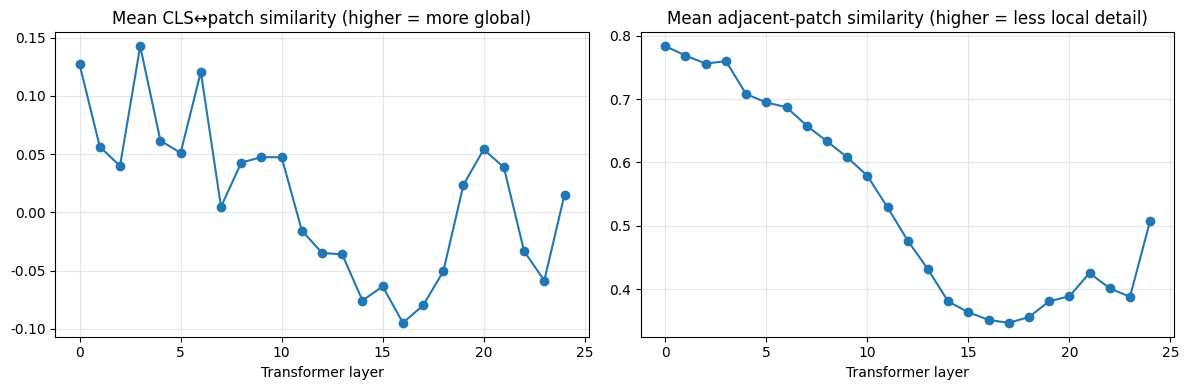

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(layers, cls2grid_sim, "o-")
axes[0].set_title("Mean CLS\u2194patch similarity (higher = more global)")
axes[1].plot(layers, neighbor_sim, "o-")
axes[1].set_title("Mean adjacent-patch similarity (higher = less local detail)")
for ax in axes:
    ax.set_xlabel("Transformer layer"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
print(f"第 23 层(LLaVA 所用):  CLS-grid 相似度 {cls2grid_sim[-2]:.3f},  相邻 patch 相似度 {neighbor_sim[-2]:.3f}")
print(f"第 24 层:             CLS-grid 相似度 {cls2grid_sim[-1]:.3f},  相邻 patch 相似度 {neighbor_sim[-1]:.3f}")

第 23 层(LLaVA 所用):  CLS-grid 相似度 -0.058,  相邻 patch 相似度 0.388
第 24 层:             CLS-grid 相似度 0.015,  相邻 patch 相似度 0.508


In [63]:
with torch.no_grad():
    attn_outs = model(**inputs, output_attentions=True)

In [68]:
last_attn = attn_outs.attentions[-1]
last_attn

tensor([[[[1.1138e-01, 8.9842e-03, 1.3824e-03,  ..., 3.5772e-05,
           1.1909e-03, 1.0492e-04],
          [1.7391e-02, 1.8367e-02, 2.4008e-03,  ..., 1.3541e-03,
           1.9095e-03, 1.2291e-03],
          [3.6664e-02, 4.8068e-03, 4.7778e-03,  ..., 1.1055e-03,
           2.4729e-03, 2.7564e-03],
          ...,
          [7.8126e-02, 4.4711e-03, 3.0215e-03,  ..., 1.9098e-03,
           2.8797e-03, 1.2141e-03],
          [2.2797e-02, 4.1896e-03, 3.0043e-03,  ..., 1.1240e-03,
           4.4812e-03, 1.3568e-03],
          [3.4055e-02, 3.4175e-03, 5.2007e-03,  ..., 1.4295e-03,
           3.3825e-03, 3.8314e-03]],

         [[1.9208e-01, 1.2187e-02, 1.1241e-03,  ..., 2.6045e-04,
           4.2110e-04, 2.0027e-04],
          [1.1715e-02, 1.2033e-02, 2.5453e-03,  ..., 2.5628e-03,
           2.7888e-03, 1.3700e-03],
          [1.3401e-02, 4.6317e-03, 3.1223e-03,  ..., 3.2457e-03,
           5.5173e-03, 1.7695e-03],
          ...,
          [4.3865e-03, 4.7505e-03, 5.4410e-03,  ..., 5.2200

In [69]:
print(last_attn.shape)

torch.Size([1, 16, 257, 257])


In [67]:
last_attn = attn_outs.attentions[-1]
cls_attn = last_attn[0, :, 0, 1:].mean(dim=0)
grid = cls_attn.reshape(n_patch_per_side, n_patch_per_side).cpu().numpy()

findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Fon

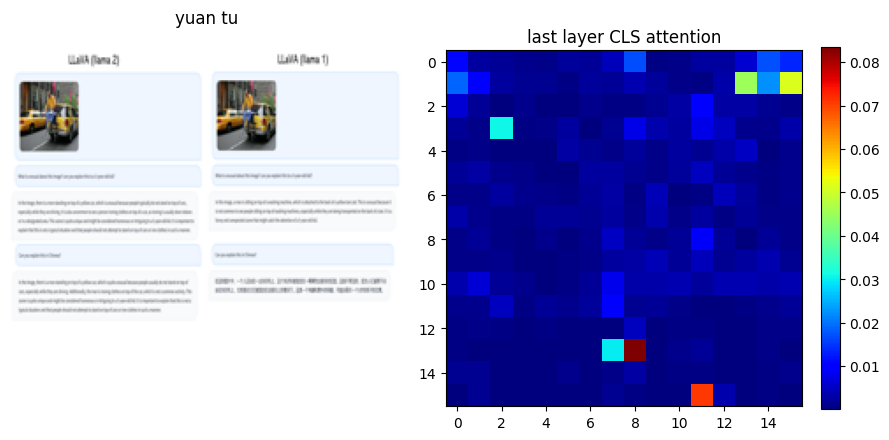

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(image.resize((224, 224))); axes[0].set_title("yuan tu"); axes[0].axis("off")
im = axes[1].imshow(grid, cmap="jet"); axes[1].set_title("last layer CLS attention")
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()